#Study Case LAB AI

##1. Data Understanding

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive
file_path = '/content/drive/MyDrive/data-bank.csv'

try:
    df = pd.read_csv(file_path)
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
df.columns = df.columns.str.strip()
target = 'Bankrupt?'

if target not in df.columns:
    print(f"ERROR: Kolom target '{target}' tidak ditemukan.")
    exit()

X = df.drop(target, axis=1)
y = df[target]
# Simpan nama kolom fitur untuk Poin 6
features = X.columns

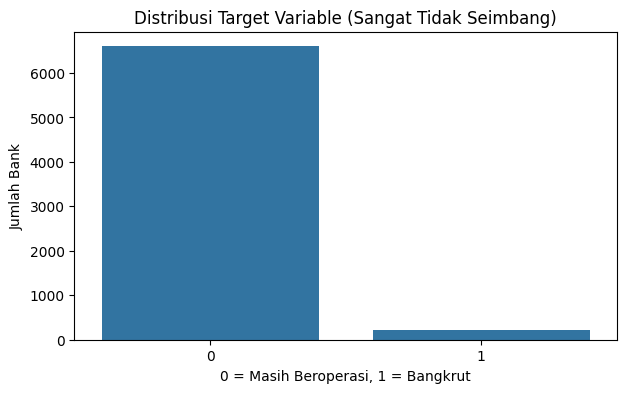

/tmp/ipython-input-3594321213.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df[target] == 0]['ROA(C) before interest and depreciation before interest'], label='Sehat (0)', shade=True)
/tmp/ipython-input-3594321213.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df[target] == 1]['ROA(C) before interest and depreciation before interest'], label='Bangkrut (1)', shade=True)


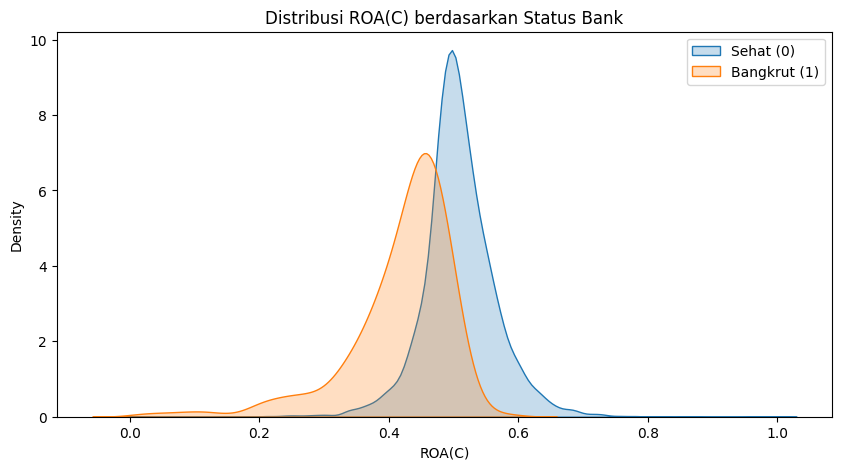

In [ ]:
# Visualisasi Imbalance
plt.figure(figsize=(7, 4))
sns.countplot(x=target, data=df)
plt.title('Distribusi Target Variable (Sangat Tidak Seimbang)')
plt.xlabel('0 = Masih Beroperasi, 1 = Bangkrut')
plt.ylabel('Jumlah Bank')
plt.show()

# Visualisasi 2 variabel vs target (Contoh: ROA(C))
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df[target] == 0]['ROA(C) before interest and depreciation before interest'], label='Sehat (0)', shade=True)
sns.kdeplot(df[df[target] == 1]['ROA(C) before interest and depreciation before interest'], label='Bangkrut (1)', shade=True)
plt.title('Distribusi ROA(C) berdasarkan Status Bank')
plt.xlabel('ROA(C)')
plt.legend()
plt.show()

##2. DATA PREPARATION

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Data dibagi: {X_train.shape} (Train), {X_test.shape} (Test)")

Data dibagi: (4773, 95) (Train), (2046, 95) (Test)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data di-scale menggunakan StandardScaler.")

Data di-scale menggunakan StandardScaler.


In [ ]:
print("\nDistribusi data latih SEBELUM balancing:")
print(y_train.value_counts())


Distribusi data latih SEBELUM balancing:
Bankrupt?
0    4619
1     154
Name: count, dtype: int64


In [ ]:
# --- Sel #9 (Modifikasi dengan SMOTE) ---

# Pastikan Anda sudah import SMOTE di sel atas:
# from imblearn.over_sampling import SMOTE
# dan sudah !pip install imblearn

print("Meratakan data menggunakan SMOTE...")
smote = SMOTE(random_state=42)

# SMOTE akan meratakan X_train_scaled (dari Sel #7) dan y_train (dari Sel #6)
# Dia akan membuat data sintetis baru untuk kelas 1
# dan langsung mengembalikan data latih yang baru dan seimbang
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Data selesai di-SMOTE.")
print("\nDistribusi data latih SETELAH balancing (SMOTE):")
print(pd.Series(y_train_balanced).value_counts())

Meratakan data menggunakan SMOTE...
Data selesai di-SMOTE.

Distribusi data latih SETELAH balancing (SMOTE):
Bankrupt?
0    4619
1    4619
Name: count, dtype: int64


##3. MODELING

In [ ]:
# Inisialisasi model dengan class_weight
rf_model_weighted = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # <-- Tambahkan ini
)

print("Melatih model RF dengan class_weight='balanced'...")

# Latih model pada data latih asli (yang scaled, tapi TIDAK balanced)
# X_train_scaled (dari Sel #7) dan y_train (asli, dari Sel #6)
rf_model_weighted.fit(X_train_scaled, y_train)

print("Model selesai dilatih.")

# --- PERBAIKAN: Sel #12 (Versi A) ---
# Sekarang evaluasi model baru ini
y_pred_weighted = rf_model_weighted.predict(X_test_scaled)

Melatih model RF dengan class_weight='balanced'...
Model selesai dilatih.


In [ ]:
# Buat prediksi pada data TES (X_test_scaled)
y_pred = rf_model.predict(X_test_scaled)

# 1. Akurasi
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}")

# 2. Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"(True Negative: {cm[0][0]}, False Positive: {cm[0][1]})")
print(f"(False Negative: {cm[1][0]}, True Positive: {cm[1][1]})")

# 3. Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)']))

Akurasi Keseluruhan: 0.9697

Confusion Matrix:
[[1965   15]
 [  47   19]]
(True Negative: 1965, False Positive: 15)
(False Negative: 47, True Positive: 19)

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.98      0.99      0.98      1980
Bangkrut (1)       0.56      0.29      0.38        66

    accuracy                           0.97      2046
   macro avg       0.77      0.64      0.68      2046
weighted avg       0.96      0.97      0.96      2046



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Ambil nilai pentingnya fitur dari model
importances = rf_model.feature_importances_

# Buat DataFrame agar mudah dibaca
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

In [ ]:
top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("5 Fitur Teratas yang Mempengaruhi Kebangkrutan:")
print(top_5_features)

5 Fitur Teratas yang Mempengaruhi Kebangkrutan:
                                 Feature  Importance
39                  Borrowing dependency    0.062060
67     Retained Earnings to Total Assets    0.045672
85            Net Income to Total Assets    0.045076
90                   Liability to Equity    0.042010
9   Continuous interest rate (after tax)    0.041704
